# Cohort Retention Analysis
 
**This analysis examines user engagement and retention using historical activity data.  
By applying cohort-based methods, it explores how user behavior evolves after initial engagement, highlighting patterns of early churn, long-term retention, and differences across acquisition periods.**


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

In [2]:
data = pd.read_csv('/Users/alesyaalieva/Documents/Data_analysis_25/GitHub_portfolio/MobileApp/users_data.csv', index_col=0)

data['dlk_cob_date'] = pd.to_datetime(data['dlk_cob_date']) 
#dlk_cob_date - user activity data

## Data Overview & Quality Checks
The dataset was inspected to validate its structure, completeness and time coverage.
Special attention was given to user-day level duplicates, as multiple events recorded for the same user on the same day may inflate activity-based metrics.

In [3]:
# Inspect dataset size, number of unique users, and overall date coverage
print("Rows:", len(data))
print("Users:", data["user_id"].nunique())
print("Date range:", data["dlk_cob_date"].min(), "—", data["dlk_cob_date"].max())


# Check for missing values in activity dates
print("Missing dates:", data["dlk_cob_date"].isna().sum())


# Check for fully duplicated rows (potential data ingestion or loading issues)
print("Duplicates:", data.duplicated().sum())

Rows: 171196
Users: 9793
Date range: 2023-01-01 00:00:00 — 2024-10-19 00:00:00
Missing dates: 0
Duplicates: 0


In [4]:
# Remove records with missing activity dates
data = data.dropna(subset=["dlk_cob_date"])

In [5]:
# Analyze distribution of active days per user
data.groupby("user_id")["dlk_cob_date"].nunique().describe()

count    9793.000000
mean       17.481466
std        35.732194
min         1.000000
25%         1.000000
50%         3.000000
75%        15.000000
max       342.000000
Name: dlk_cob_date, dtype: float64

#### First Insights
- The median equals 3, meaning that half of the users were active on three days or fewer.
- The mean is higher than the median, indicating a right-skewed distribution driven by more active users.
- The maximum value is substantially higher than the median, suggesting the presence of highly engaged power users.

This pattern may indicate potential activation challenges, as a large share of users exhibits low activity levels, while a smaller segment forms a highly engaged user core.

In [6]:
# Analyze activity volume over time (monthly aggregation)

data["dlk_cob_date"].dt.to_period("M").value_counts().sort_index()

2023-01      314
2023-02      421
2023-03      980
2023-04     2632
2023-05     3042
2023-06     3799
2023-07     4280
2023-08     6097
2023-09     6375
2023-10     7987
2023-11     8964
2023-12    10003
2024-01     7863
2024-02     9751
2024-03    10608
2024-04    12062
2024-05    12778
2024-06    12712
2024-07    14731
2024-08    14162
2024-09    12912
2024-10     8723
Freq: M, Name: dlk_cob_date, dtype: int64

In [7]:
# Check for duplicates at the user-day level. If multiple events occur for the same user on the same day, 
# the data should be aggregated to a unique user-day level to ensure accurate activity measurement.

data.duplicated(subset=["user_id", "dlk_cob_date"]).sum()

0

### Exploratory Data Analysis Summary

The dataset contains user activity records over the period from **2023-01-01** to **2024-10-19**, covering **9793 unique users** and **171196 activity records**.
This provides sufficient temporal coverage to analyze user retention and engagement patterns.

Several data quality checks were performed prior to analysis:

-  No missing activity dates.

-   Fully identical rows were checked to identify potential data ingestion or loading issues. No critical duplication problems were observed.

- User-day level duplicates:  No recorded for the same user on the same day were detected.



---

## Monthly Cohort Сalculation

To analyze user retention we will apply a cohort-based approach.

In [8]:
# Convert activity date to monthly period (calendar month of activity)

data['activity_month'] = data['dlk_cob_date'].dt.to_period('M')

In [9]:
data.head()

,dlk_cob_date,user_id,activity_month
0,2023-08-22,a95b0e7e-deda-4cb8-81d2-cff4a01e9077,2023-08
1,2023-06-12,4f53a875-847f-47cb-ab16-3517ca9cf92c,2023-06
2,2024-08-15,f04fb972-ff9c-41ce-8dbc-a0984e6017ae,2024-08
3,2023-12-08,1d9bcb51-351d-4679-8aba-95f38b9c56e9,2023-12
4,2024-10-15,21d807eb-1ae4-4061-a403-96b5eefdd312,2024-10


In [10]:
# Identify each user's first activity month (cohort assignment)
# transform('min') ensures that the cohort month is assigned to every row of the user

data['cohort_month'] = data.groupby('user_id')['activity_month'].transform('min')

In [11]:
data.head()

,dlk_cob_date,user_id,activity_month,cohort_month
0,2023-08-22,a95b0e7e-deda-4cb8-81d2-cff4a01e9077,2023-08,2023-03
1,2023-06-12,4f53a875-847f-47cb-ab16-3517ca9cf92c,2023-06,2023-04
2,2024-08-15,f04fb972-ff9c-41ce-8dbc-a0984e6017ae,2024-08,2023-12
3,2023-12-08,1d9bcb51-351d-4679-8aba-95f38b9c56e9,2023-12,2023-07
4,2024-10-15,21d807eb-1ae4-4061-a403-96b5eefdd312,2024-10,2023-04


In [12]:
# Calculate the cohort period index (months since first activity)
# Periods are converted to integer representation and subtracted
# This gives the number of months elapsed since cohort start

data['period_number'] = (
    data['activity_month'].astype(int)
    - data['cohort_month'].astype(int))

In [13]:
data.head()

,dlk_cob_date,user_id,activity_month,cohort_month,period_number
0,2023-08-22,a95b0e7e-deda-4cb8-81d2-cff4a01e9077,2023-08,2023-03,5
1,2023-06-12,4f53a875-847f-47cb-ab16-3517ca9cf92c,2023-06,2023-04,2
2,2024-08-15,f04fb972-ff9c-41ce-8dbc-a0984e6017ae,2024-08,2023-12,8
3,2023-12-08,1d9bcb51-351d-4679-8aba-95f38b9c56e9,2023-12,2023-07,5
4,2024-10-15,21d807eb-1ae4-4061-a403-96b5eefdd312,2024-10,2023-04,18


In [14]:
# Count unique active users for each cohort and period
# Each cell represents number of users from a cohort active in a given month

cohort_data = (
    data.groupby(['cohort_month', 'period_number'])['user_id']
    .nunique()
    .reset_index()
)

cohort_data.head()

,cohort_month,period_number,user_id
0,2023-01,0,162
1,2023-01,1,81
2,2023-01,2,86
3,2023-01,3,85
4,2023-01,4,74


In [15]:
# Reshape data into cohort retention matrix
# Rows = cohort month
# Columns = months since first activity

cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='period_number',
    values='user_id'
)

In [16]:
cohort_pivot

period_number,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
cohort_month,,,,,,,,,,,,,,,,,,,,,
2023-01,162.0,81.0,86.0,85.0,74.0,66.0,71.0,68.0,69.0,70.0,...,50.0,52.0,48.0,51.0,47.0,52.0,47.0,38.0,40.0,36.0
2023-02,138.0,47.0,52.0,48.0,44.0,44.0,41.0,29.0,38.0,41.0,...,41.0,37.0,39.0,37.0,30.0,34.0,35.0,27.0,24.0,NaN
2023-03,301.0,141.0,109.0,108.0,85.0,90.0,75.0,81.0,86.0,82.0,...,74.0,78.0,80.0,72.0,75.0,79.0,73.0,61.0,NaN,NaN
2023-04,591.0,229.0,201.0,178.0,183.0,172.0,171.0,162.0,142.0,131.0,...,132.0,135.0,134.0,132.0,124.0,113.0,105.0,NaN,NaN,NaN
2023-05,480.0,194.0,165.0,162.0,128.0,124.0,120.0,109.0,89.0,100.0,...,87.0,94.0,92.0,97.0,76.0,65.0,NaN,NaN,NaN,NaN
2023-06,589.0,223.0,192.0,164.0,170.0,168.0,158.0,113.0,113.0,113.0,...,113.0,108.0,91.0,89.0,77.0,NaN,NaN,NaN,NaN,NaN
2023-07,543.0,223.0,161.0,162.0,159.0,156.0,107.0,111.0,112.0,105.0,...,104.0,92.0,99.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,743.0,298.0,249.0,218.0,208.0,166.0,172.0,156.0,149.0,149.0,...,135.0,119.0,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,752.0,294.0,242.0,209.0,151.0,162.0,127.0,120.0,128.0,130.0,...,115.0,77.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# Cohort size = number of users in period 0 (first activity month)
cohort_size = cohort_pivot.iloc[:, 0]

# Retention rate = share of cohort active in each subsequent period
retention = cohort_pivot.divide(cohort_size, axis=0)

In [18]:
cohort_size

cohort_month
2023-01    162.0
2023-02    138.0
2023-03    301.0
2023-04    591.0
2023-05    480.0
2023-06    589.0
2023-07    543.0
2023-08    743.0
2023-09    752.0
2023-10    833.0
2023-11    709.0
2023-12    683.0
2024-01    370.0
2024-02    386.0
2024-03    360.0
2024-04    393.0
2024-05    341.0
2024-06    356.0
2024-07    369.0
2024-08    256.0
2024-09    258.0
2024-10    180.0
Freq: M, Name: 0, dtype: float64

In [19]:
retention

period_number,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
cohort_month,,,,,,,,,,,,,,,,,,,,,
2023-01,1.0,0.500000,0.530864,0.524691,0.456790,0.407407,0.438272,0.419753,0.425926,0.432099,...,0.308642,0.320988,0.296296,0.314815,0.290123,0.320988,0.290123,0.234568,0.246914,0.222222
2023-02,1.0,0.340580,0.376812,0.347826,0.318841,0.318841,0.297101,0.210145,0.275362,0.297101,...,0.297101,0.268116,0.282609,0.268116,0.217391,0.246377,0.253623,0.195652,0.173913,NaN
2023-03,1.0,0.468439,0.362126,0.358804,0.282392,0.299003,0.249169,0.269103,0.285714,0.272425,...,0.245847,0.259136,0.265781,0.239203,0.249169,0.262458,0.242525,0.202658,NaN,NaN
2023-04,1.0,0.387479,0.340102,0.301184,0.309645,0.291032,0.289340,0.274112,0.240271,0.221658,...,0.223350,0.228426,0.226734,0.223350,0.209814,0.191201,0.177665,NaN,NaN,NaN
2023-05,1.0,0.404167,0.343750,0.337500,0.266667,0.258333,0.250000,0.227083,0.185417,0.208333,...,0.181250,0.195833,0.191667,0.202083,0.158333,0.135417,NaN,NaN,NaN,NaN
2023-06,1.0,0.378608,0.325976,0.278438,0.288625,0.285229,0.268251,0.191851,0.191851,0.191851,...,0.191851,0.183362,0.154499,0.151104,0.130730,NaN,NaN,NaN,NaN,NaN
2023-07,1.0,0.410681,0.296501,0.298343,0.292818,0.287293,0.197053,0.204420,0.206262,0.193370,...,0.191529,0.169429,0.182320,0.128913,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,1.0,0.401077,0.335128,0.293405,0.279946,0.223419,0.231494,0.209960,0.200538,0.200538,...,0.181696,0.160162,0.117093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,1.0,0.390957,0.321809,0.277926,0.200798,0.215426,0.168883,0.159574,0.170213,0.172872,...,0.152926,0.102394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Cohort Calculation Methodology

To analyze user retention, a cohort-based approach was applied.

Each user was assigned to a cohort based on the month of their first recorded activity.
Subsequent activity was tracked in monthly intervals relative to that first activity month.

For each cohort, we measured how many users returned in later months.
Retention was calculated as the share of users from the original cohort who remained active in each period.

This results in a cohort retention matrix where:
- Rows represent acquisition cohorts (first activity month)
- Columns represent months since initial activity
- Values represent the proportion of users who remained active

This structure allows comparison of engagement patterns across different user cohorts over time.

___

## Heatmap

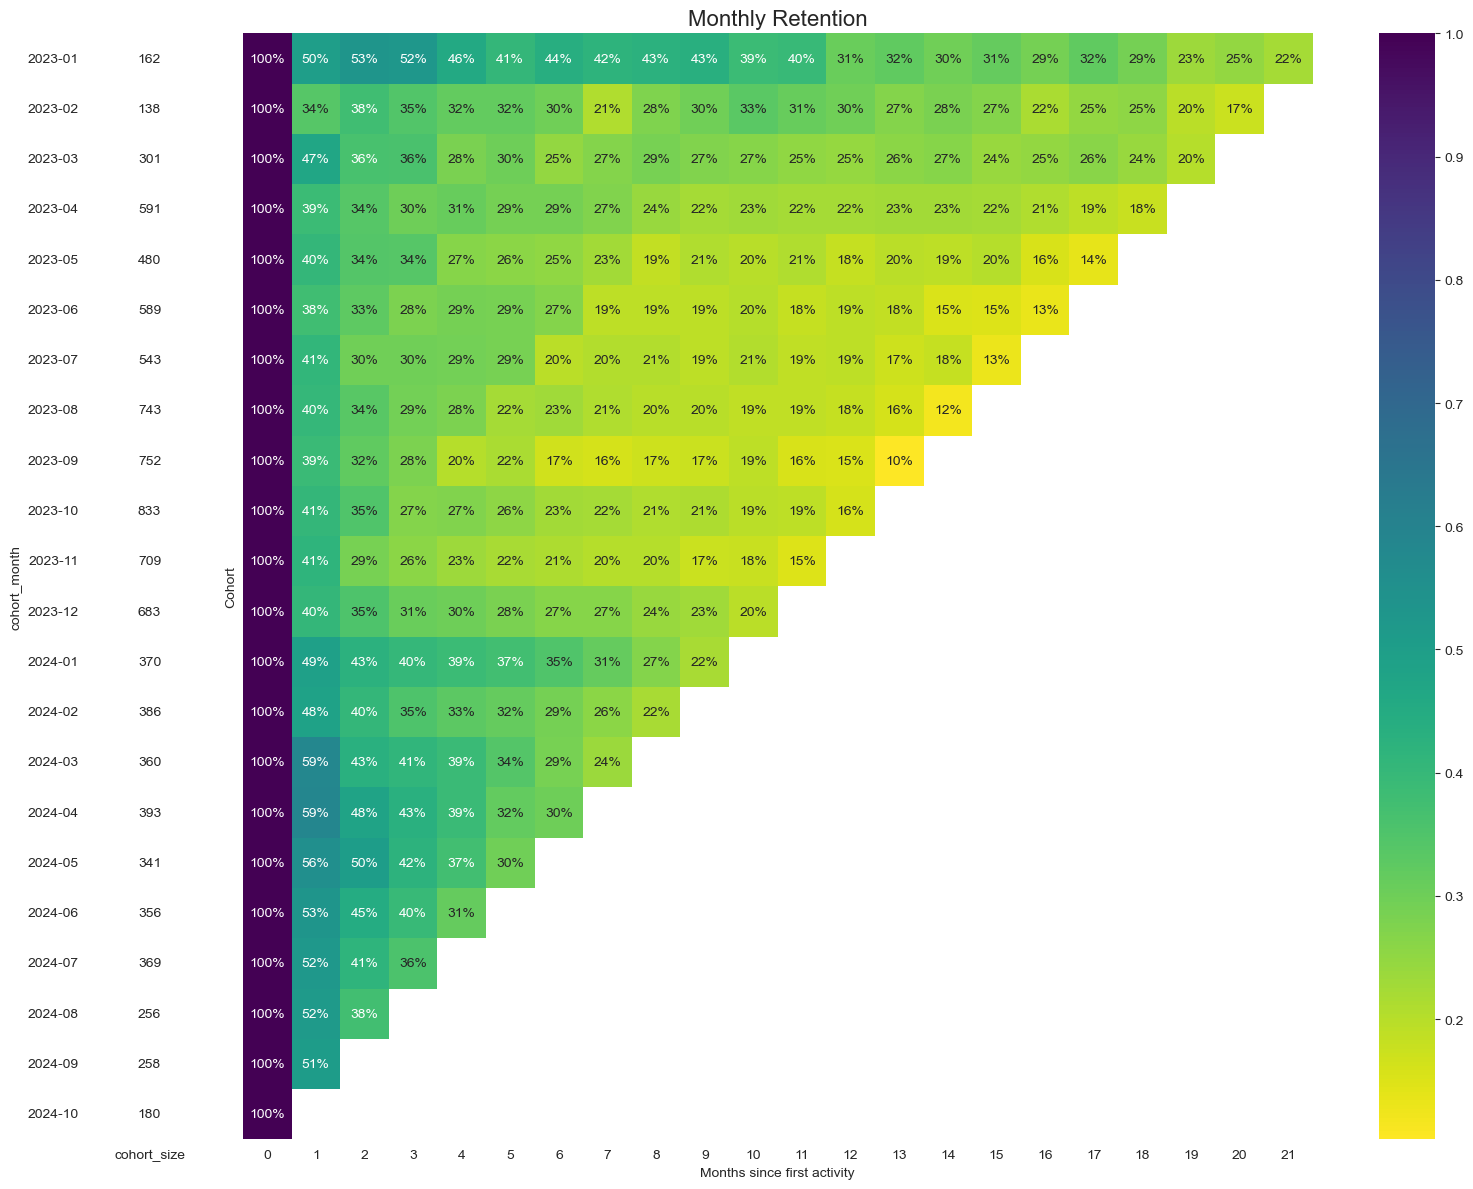

In [20]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Heatmap of retention rates
    sns.heatmap(retention,
                mask=retention.isnull(),
                annot=True,
                fmt='.0%',
                cmap='viridis_r',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='Months since first activity', ylabel='Cohort')

    # ТHeatmap of cohort sizes
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

### Cohort Retention Insights


- **Early retention drop**   
Across most cohorts, the largest decline occurs between the first and second month of activity.
This indicates substantial early churn following initial engagement, suggesting that user activation remains a critical stage of the lifecycle.

- **Long-term engagement stability**  
After the initial drop, retention gradually stabilizes, with a meaningful share of users remaining active over extended periods.
Older cohorts retain approximately 20–30% of users even after more than a year, indicating the presence of a loyal and consistently engaged user base.

- **Improvement in newer cohorts**   
More recent cohorts demonstrate higher early retention compared to earlier cohorts.
This suggests a potential improvement in user onboarding, product experience, or acquisition quality over time.

- **Cohort performance differences**   
Retention varies across cohorts, indicating that user behavior may differ depending on acquisition period or external factors such as seasonality or product changes.



--- 

## Retention Curve Visualization

To better understand retention dynamics over time, cohort retention rates were plotted as continuous curves.

Each line represents a user cohort and shows how the proportion of active users changes as time passes since their first activity.

This visualization helps identify:
- early churn intensity
- long-term retention stability
- differences between cohorts
- retention improvement trends over time

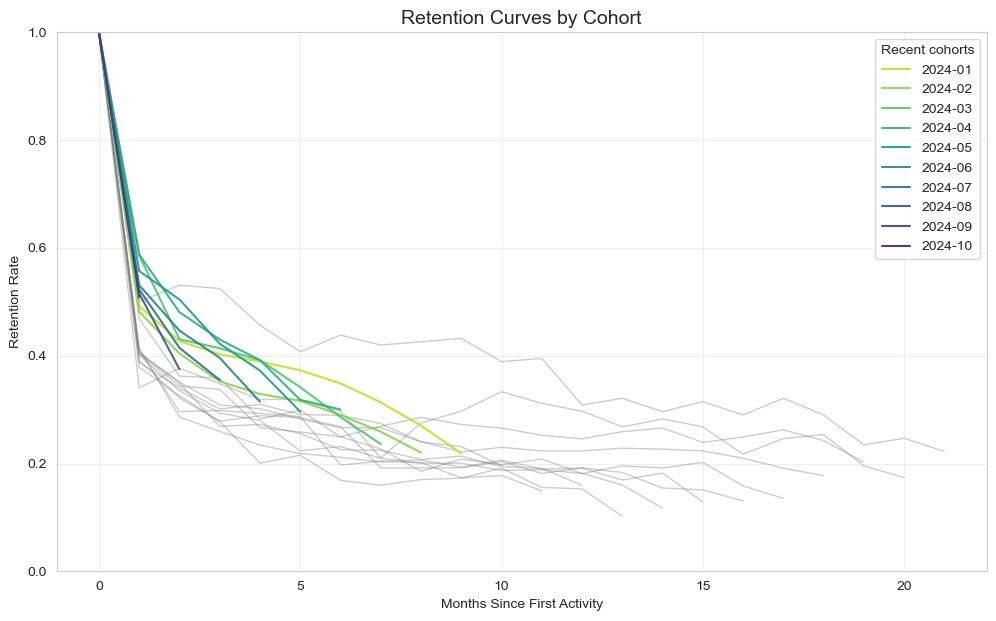

In [21]:
# periods on x-axis, cohorts as separate lines

retention_curves = retention.T
cutoff = pd.Period("2024-01", freq="M")

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

recent_cohorts = [c for c in retention_curves.columns if c >= cutoff]
palette = sns.color_palette("viridis_r", len(recent_cohorts))
color_map = dict(zip(recent_cohorts, palette))

for cohort in retention_curves.columns:
    if cohort >= cutoff:
        plt.plot(retention_curves.index,
                 retention_curves[cohort],
                 linewidth=1.5,
                 alpha=0.9,
                 color=color_map[cohort],
                 label=str(cohort))
    else:
        plt.plot(retention_curves.index,
                 retention_curves[cohort],
                 linewidth=1,
                 alpha=0.4,
                 color="gray")

plt.title("Retention Curves by Cohort", fontsize=14)
plt.xlabel("Months Since First Activity")
plt.ylabel("Retention Rate")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend(title="Recent cohorts")
plt.show()

### Retention Curve Interpretation
- **Early churn pattern**        
 Most cohorts show a steep decline during the first months after initial activity.
This indicates that the largest share of user loss occurs early in the lifecycle, which is typical for many digital products.


- **Retention stabilization**    
After the initial drop, retention curves tend to flatten.
This suggests that users who remain active beyond early periods are significantly more likely to continue using the product long-term.


- **Loyal user base**    
The long tail of the curves indicates sustained engagement among a core group of users.
This reflects the presence of a stable and loyal user segment.


- **Cohort performance differences**   
Retention curves are not identical across cohorts, indicating variability in user behavior depending on acquisition period or external factors.


- **Retention improvement over time**    
More recent cohorts appear to maintain higher retention levels in early periods compared to older cohorts, suggesting improvements in user experience, onboarding, or acquisition quality.